# Real SageMaker Multi-Turn RL: train, evaluate, deploy, compare

Everything in this notebook runs on **real AWS resources** (account `384887233198`, region `us-west-2`) and follows the official guide:
[Multi-turn reinforcement learning in SageMaker AI](https://docs.aws.amazon.com/sagemaker/latest/dg/model-customize-mtrl.html).

| Step | Official API | What you will see |
|---|---|---|
| Baseline | `MultiTurnRLEvaluator(model="openai-reasoning-gpt-oss-20b")` | How the untrained model performs |
| Train | `MultiTurnRLTrainer(...).train()` → `job.wait()` | A real MTRL job producing a LoRA adapter |
| Evaluate | `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` | Base vs fine-tuned, same prompts |
| Inference (recorded) | MLflow traces of that evaluation | Real conversations of both models, side by side |
| Deploy, option 1 | `ModelBuilder(model=ModelPackage).build()` → `deploy()` | A real-time endpoint with the fine-tuned model (attempted: no GPU capacity was available) |
| Deploy, option 2 | Amazon Bedrock Custom Model Import | The fine-tuned model, serverless |
| Inference (live) | The same agent with each model | The same held-out tickets: base model on Bedrock vs the fine-tuned model |

See [HOW_IT_WORKS.md](../HOW_IT_WORKS.md) for diagrams of every step.

**Run modes.** By default the notebook is in *replay* mode: it re-attaches to the recorded jobs and shows their real results, and submits nothing. A billable step runs only when its exact confirmation phrase is supplied through an environment variable (`MTRL_TRAIN_CONFIRMATION`, `MTRL_COMPARISON_CONFIRMATION`, `MTRL_DEPLOY_CONFIRMATION`, `MTRL_BEDROCK_IMPORT_CONFIRMATION`), or live inference is turned on with `MTRL_LIVE_INFERENCE=1`. A recorded job is always re-attached, never submitted twice. Select the **Python 3.12 (AWS MTRL)** kernel.

Commands below run from the project root. **Before deploying** (section 9), start the safety watchdog in a terminal: `python scripts/09a_watchdog.py`. Deployment refuses to start without it. **After executing**, remove the temporary MLflow sign-in links the SDK prints: `python scripts/dev/scrub_notebook.py <executed notebook>`.

In [1]:
import logging
import os
import sys
from pathlib import Path

for noisy in ("sagemaker", "botocore", "boto3", "urllib3", "httpx", "mlflow", "strands", "openai"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

# The project root holds aws/ and agent/; Jupyter may start here or in notebooks/.
ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "aws" / "workflow.py").is_file())
for folder in (ROOT / "agent", ROOT):  # the agent's modules and the aws package
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

from aws.config import DemoConfig

# Pin every AWS client to the demo region before boto3 or the SDK load.
os.environ["AWS_DEFAULT_REGION"] = os.environ["AWS_REGION"] = DemoConfig().region

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from aws.workflow import MtrlDemoWorkflow

workflow = MtrlDemoWorkflow()
config = workflow.config

TRAIN_CONFIRMATION = os.environ.get("MTRL_TRAIN_CONFIRMATION", "")
COMPARISON_CONFIRMATION = os.environ.get("MTRL_COMPARISON_CONFIRMATION", "")
DEPLOY_CONFIRMATION = os.environ.get("MTRL_DEPLOY_CONFIRMATION", "")
BEDROCK_IMPORT_CONFIRMATION = os.environ.get("MTRL_BEDROCK_IMPORT_CONFIRMATION", "")
LIVE_INFERENCE = os.environ.get("MTRL_LIVE_INFERENCE") == "1"

from aws.reporting.report_tables import KEY_METRICS  # headline metrics and their plain-language labels

billable = [p for p in (TRAIN_CONFIRMATION, COMPARISON_CONFIRMATION, DEPLOY_CONFIRMATION,
                         BEDROCK_IMPORT_CONFIRMATION) if p] + (["live inference"] if LIVE_INFERENCE else [])
print("Mode:", "RUN (confirmed billable steps may execute)" if billable else "REPLAY (no new jobs)")

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: ~/Library/Application Support/sagemaker/config.yaml


Mode: REPLAY (no new jobs)


## 1. Verify the real AWS setup

Caller identity, region, supported model, the deployed AgentCore runtime (our support agent), the MLflow app, and both prompt sets.

In [2]:
validation = workflow.validate()
for name, value in validation.items():
    print(f"{name:20s} {value}")

account_id           384887233198
caller_arn           arn:aws:iam::384887233198:user/mlflow
region               us-west-2
model                openai-reasoning-gpt-oss-20b
agent_runtime_arn    arn:aws:bedrock-agentcore:us-west-2:384887233198:runtime/mtrl_support_agent-OAXxBY5ULs
training_prompts     64
evaluation_prompts   32
mlflow_app_arn       arn:aws:sagemaker:us-west-2:384887233198:mlflow-app/app-N7OYBKIHZSQR
agent_runtime_status READY
mlflow_app_status    Created


## 2. Prompt datasets

64 training tickets and 32 **held-out** evaluation tickets (never used for training). SageMaker requires more training prompts than the batch size (32). Uploading is idempotent: unchanged files are not re-uploaded.

In [3]:
uploads = workflow.upload_datasets()
for split, info in uploads.items():
    action = "uploaded" if info["uploaded"] else "unchanged, existing S3 object kept"
    print(f"{split:10s} {info['uri']}  ->  {action}")

prompts = pd.read_csv(ROOT / "data/training_prompts.csv")
print(f"\n{len(prompts)} training tickets, for example:")
for text in prompts["prompt"].head(3):
    print("  -", text)

training   s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/training_prompts.parquet  ->  unchanged, existing S3 object kept
evaluation s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/evaluation_prompts.parquet  ->  unchanged, existing S3 object kept

64 training tickets, for example:
  - Resolve the customer's internet outage. Customer says: My internet is not working.
  - Resolve the customer's internet outage. Customer says: I am connected to Wi-Fi but cannot reach the internet.
  - Resolve the customer's internet outage. Customer says: My router's WAN light is red.


## 3. Budget check (hard cap: $25)

Spent amounts are the token counts AWS actually billed (`BillableTokenUsage`). Planned amounts scale this account's measured per-rollout usage with a 1.5x safety margin, plus the endpoint's maximum lifetime at the official hourly price. The guard refuses any plan above the cap.

In [4]:
from aws.costs.cost_guard import MtrlCostGuard

ledger = workflow.ledger()
guard = MtrlCostGuard.from_price_list(config)
budget = guard.evaluate(ledger.measured_reference(), ledger.spent(), ledger.remaining())
display(pd.DataFrame(budget["lines"]).rename(columns={"item": "Cost item", "usd": "USD"}))
print(f"Projected total: ${budget['projected_total_usd']:.2f} of the hard ${budget['budget_cap_usd']} cap")

,Cost item,USD
0,Base evaluation (first attempt),0.0069
1,Base evaluation,0.0341
2,Training,2.8296
3,Comparison: base model,0.0355
4,Comparison: fine-tuned model,0.0362
5,Cross-region copy of weights to us-east-1 (41....,0.8400
6,Bedrock imported model inference (estimate: 1 ...,2.0000
7,Endpoint uptime,0.0000
8,"Contingency (AgentCore, CodeBuild, S3, logs)",2.0000


Projected total: $7.78 of the hard $25 cap


## 4. The task the agent must learn

A customer reports that their internet is down. The agent (GPT-OSS-20B inside a Strands agent on Bedrock AgentCore) has **4 turns**. Each turn it picks one action through a tool. Only one action per situation moves the diagnosis forward. Each correct step earns 0.25; restoring the connection earns 1.0. One wrong action wastes a turn, so the episode ends one step short.

In [5]:
from environment import ACTIONS, MAX_PROGRESS, SUCCESS_PATH, TRANSITIONS

rows = []
for step, state in enumerate(SUCCESS_PATH[:-1], start=1):
    correct = next(action for (source, action) in TRANSITIONS if source == state)
    rows.append({
        "Turn": step,
        "Situation": state,
        "Correct action": correct,
        "Tempting alternatives": ", ".join(a for a in ACTIONS[state] if a != correct),
        "Reward after this step": step / MAX_PROGRESS,
    })
display(pd.DataFrame(rows))

,Turn,Situation,Correct action,Tempting alternatives,Reward after this step
0,1,new_ticket,check_outage,"restart_router, close_ticket",0.25
1,2,no_outage,inspect_router_lights,"restart_router, close_ticket",0.50
2,3,red_wan_light,check_account_config,"replace_router, close_ticket",0.75
3,4,config_mismatch,apply_config_fix,"escalate, close_ticket",1.00


## 5. Baseline: the base model before training

A real SageMaker evaluation of the untrained GPT-OSS-20B through our agent: 32 held-out tickets, 2 attempts each. The usual mistake is the shortcut `restart_router`, which wastes a turn.

In [6]:
baseline = workflow.base_evaluation_evidence()
base_metrics = baseline["metrics"]
print("SageMaker pipeline execution:", baseline["execution"]["arn"])
display(pd.DataFrame(
    [{"Metric": label, "Base model": base_metrics[key]} for key, label in KEY_METRICS.items()]
))

SageMaker pipeline execution: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/7kz12i8e43ip


,Metric,Base model
0,Ticket fully solved (pass@1),0.50000
1,Solved in 1 of 2 tries (pass@2),0.84375
2,Mean reward (with partial credit),0.87500
3,Rollouts fully solved,32.00000
4,Rollouts not fully solved,32.00000
5,Model calls per rollout,5.84375


## 6. Training: `MultiTurnRLTrainer` (official guide)

Approved size: **10 training steps**, each on **32 tickets x 4 rollouts** (1,280 rollouts in total). The job runs our agent on AgentCore for every rollout, scores each full conversation with the environment's reward, and updates a LoRA adapter on GPT-OSS-20B.

In [7]:
training = workflow.training_stage()
trainer = training.build_trainer()
hp = trainer.hyperparameters
display(pd.DataFrame([
    ("Base model", trainer.model),
    ("Agent environment (AgentCore runtime)", trainer.agent_env),
    ("Training prompts", trainer.training_dataset),
    ("Training steps", hp.max_steps),
    ("Rollouts per prompt (group size)", hp.group_size),
    ("Global batch size", hp.global_batch_size),
    ("Learning rate", hp.learning_rate),
    ("LoRA rank / alpha", f"{hp.lora_rank} / {hp.lora_alpha}"),
    ("Policy loss", hp.loss_fn),
], columns=["Setting", "Value"]))

,Setting,Value
0,Base model,openai-reasoning-gpt-oss-20b
1,Agent environment (AgentCore runtime),arn:aws:bedrock-agentcore:us-west-2:3848872331...
2,Training prompts,s3://sagemaker-mtrl-demo-384887233198-us-west-...
3,Training steps,10
4,Rollouts per prompt (group size),4
5,Global batch size,32
6,Learning rate,0.00001
7,LoRA rank / alpha,32 / 64
8,Policy loss,ppo


In [8]:
job = training.run_or_attach(TRAIN_CONFIRMATION)
if job is None:
    print("No training job recorded yet. Set MTRL_TRAIN_CONFIRMATION to submit one.")
else:
    print("Training job:", job.job_name)
    print("Status:      ", job.job_status)

Training job: openai-reasoning-gpt-oss-20b-mtrl-20261002040558
Status:       Completed


In [9]:
if job is not None:
    job = training.wait(job, timeout_seconds=4 * 3600)
    summary = training.summary(job)
    display(pd.DataFrame([
        ("Job", summary["job_name"]),
        ("Status", summary["job_status"]),
        ("Failure reason", summary["failure_reason"]),
        ("Duration (minutes)", summary["duration_minutes"]),
        ("Trained LoRA adapter (model package)", summary["output_model_package_arn"]),
        ("Billed tokens", summary["billable_token_usage"]),
    ], columns=["Field", "Value"]))

,Field,Value
0,Job,openai-reasoning-gpt-oss-20b-mtrl-20261002040558
1,Status,Completed
2,Failure reason,
3,Duration (minutes),19.2
4,Trained LoRA adapter (model package),arn:aws:sagemaker:us-west-2:384887233198:model...
5,Billed tokens,"{'PrefillTokenCount': 4833702, 'SampleTokenCou..."


~/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



------------------------------------------------------------------------------------------------------------------
  Training Metrics
------------------------------------------------------------------------------------------------------------------
  Step                Reward/Mean                 Turns/Mean      Training/Total Tokens  Training/Num Trajectories
------------------------------------------------------------------------------------------------------------------
     1                     0.8887                     6.4844                     534113                        128
     2                     0.8906                     6.7969                     571359                        128
     3                     0.9102                     6.8438                     575191                        128
     4                     0.9277                     6.6328                     548452                        128
     5                     0.9219                     6.6250

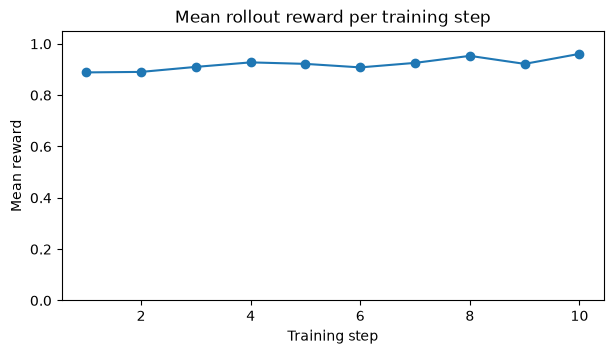

In [10]:
if job is not None and job.job_status == "Completed":
    steps = pd.DataFrame(job.get_training_metrics())
    if steps.empty:
        print("MLflow has no per-step metrics for this job yet.")
    else:
        ax = steps.plot(x="step", y="rollout/reward/mean", marker="o", legend=False, figsize=(7, 3.5))
        ax.set(title="Mean rollout reward per training step", xlabel="Training step",
               ylabel="Mean reward", ylim=(0, 1.05))
        plt.show()

## 7. Evaluation: base vs fine-tuned (official guide)

One `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` pipeline evaluates both models on the same 32 held-out tickets. Each model's metrics come from its own MLflow run.

In [11]:
evaluation = workflow.evaluation_stage()
trained_job = job if job is not None and job.job_status == "Completed" else None
execution_arn = evaluation.run_or_attach(COMPARISON_CONFIRMATION, trained_job)
status = None
if execution_arn is None:
    print("No comparison recorded yet. Set MTRL_COMPARISON_CONFIRMATION to run it.")
else:
    print("Comparison pipeline:", execution_arn)
    status = evaluation.wait(execution_arn, timeout_seconds=2 * 3600)

Comparison pipeline: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/8hvze02od4o0


  13:44:32  CreateEvaluationAction: Succeeded


  13:44:32  EvaluateBaseModel: Succeeded


  13:44:32  EvaluateFineTunedModel: Succeeded


  13:44:32  AssociateLineage: Succeeded


Pipeline Succeeded.


,Metric,Base model,Fine-tuned model
0,Ticket fully solved (pass@1),0.578125,0.781250
1,Solved in 1 of 2 tries (pass@2),0.812500,0.937500
2,Mean reward (with partial credit),0.882812,0.925781
3,Rollouts fully solved,37.000000,50.000000
4,Rollouts not fully solved,27.000000,14.000000
5,Model calls per rollout,6.093750,6.453125


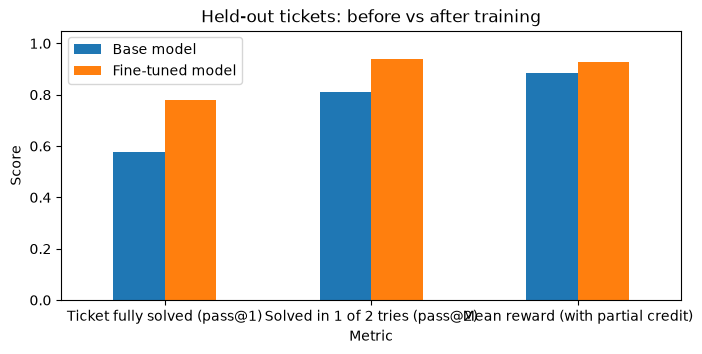

Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.


In [12]:
if status == "Succeeded":
    results = evaluation.results(execution_arn)
    comparison = pd.DataFrame([
        {"Metric": label,
         "Base model": results["base"]["metrics"].get(key),
         "Fine-tuned model": results["fine_tuned"]["metrics"].get(key)}
        for key, label in KEY_METRICS.items()
    ])
    display(comparison)
    chart = comparison.set_index("Metric").loc[[KEY_METRICS[k] for k in (
        "eval/reward/pass_at_1", "eval/reward/pass_at_2", "eval/reward/mean")]]
    ax = chart.plot.bar(figsize=(8, 3.5), rot=0, ylim=(0, 1.05))
    ax.set(title="Held-out tickets: before vs after training", ylabel="Score")
    plt.show()
    print("Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.")

## 8. Inference before vs after training, recorded by SageMaker

During the evaluation above, SageMaker ran **both models through the same agent on the same held-out tickets** and stored every conversation as an MLflow trace: the ticket, the model's reasoning, each tool call, and the reward. These are real inference results for the base and the fine-tuned model, from the same pipeline and the same serving stack, so no endpoint is needed to show them.

In [13]:
from aws.deploy.inference import side_by_side
from aws.rl.trajectories import TrajectoryReader, comparison_record

recorded = workflow.store.load(TrajectoryReader.RECORD)
if recorded is None and status == "Succeeded":
    reader = TrajectoryReader.create(workflow.session, workflow.state.mlflow_app_arn)
    order = pd.read_csv(ROOT / "data/evaluation_prompts.csv")["prompt"].tolist()
    recorded = comparison_record(reader, results, order)
    workflow.store.save(TrajectoryReader.RECORD, recorded)
if recorded:
    summary = recorded["summary"]
    print(f"Held-out tickets: {len(recorded['pairs'])} (2 tries per model each)")
    print(f"Fine-tuned model scored higher on {summary['improved']}, the same on {summary['same']}, "
          f"lower on {summary['worse']} (mean reward per ticket)")

Held-out tickets: 32 (2 tries per model each)
Fine-tuned model scored higher on 13, the same on 13, lower on 6 (mean reward per ticket)


In [14]:
LABELS = {"before": "Before training (base model)", "after": "After training (fine-tuned)"}


def show_conversation(pair, attempt=0):
    entry = {key: {"reward": pair[key][attempt]["reward"], "trace": pair[key][attempt]["steps"]}
             for key in ("before", "after")}
    print()
    print("Ticket:", pair["ticket"].split("Customer says: ")[-1])
    for key in ("before", "after"):
        thought = " ".join(pair[key][attempt]["first_thought"].split())[:220]
        print(f"  {LABELS[key]} first thought: {thought}")
    display(pd.DataFrame(side_by_side(entry, LABELS)).set_index("Turn"))


if recorded:
    print("The first three held-out tickets in dataset order (attempt 1 of 2 for each model):")
    for pair in recorded["pairs"][:3]:
        show_conversation(pair)
    changed = next((pair for pair in recorded["pairs"][3:]
                    if pair["before"][0]["reward"] < 1.0 <= pair["after"][0]["reward"]), None)
    if changed:
        print()
        print("A selected example where training changed the outcome:")
        show_conversation(changed)

The first three held-out tickets in dataset order (attempt 1 of 2 for each model):

Ticket: My Wi-Fi works, but websites do not load.
  Before training (base model) first thought: We need to choose an action. The customer says Wi-Fi works but websites do not load. That suggests DNS or routing issue. We can check outage or restart router. The first step: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The customer says Wi-Fi works but websites do not load. That suggests DNS or routing issue. We have actions: restart_router, close_ticket, check_outage. We should check for outage first. So c


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,inspect_router_lights [correct],inspect_router_lights [correct]
3,check_account_config [correct],check_account_config [correct]
4,apply_config_fix [correct],apply_config_fix [correct]
Reward,1.0,1.0



Ticket: The internet light changed from green to red.
  Before training (base model) first thought: We need to use take_support_action tool. First action: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The first step: check_outage.


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,inspect_router_lights [correct],inspect_router_lights [correct]
3,check_account_config [correct],check_account_config [correct]
4,apply_config_fix [correct],apply_config_fix [correct]
Reward,1.0,1.0



Ticket: My service stopped working after a plan change.
  Before training (base model) first thought: We need to use take_support_action tool. First action: check_outage.
  After training (fine-tuned) first thought: We need to choose an action. The customer says service stopped after plan change. We have actions: restart_router, close_ticket, check_outage. Likely check_outage first.


,Before training (base model),After training (fine-tuned)
Turn,,
1,check_outage [correct],check_outage [correct]
2,restart_router [wasted turn],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



A selected example where training changed the outcome:

Ticket: Every browser reports that I am offline.
  Before training (base model) first thought: We need to choose an action. The first step: likely restart_router. Use tool.
  After training (fine-tuned) first thought: We need to choose an action. The first step: check outage.


,Before training (base model),After training (fine-tuned)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0


## 9. Deploy option 1: SageMaker real-time endpoint (official guide)

`ModelPackage.get(...)` → `ModelBuilder(model=package).build()` → `deploy(...)`. For this training output, SageMaker serves the **fine-tuned model**: the trained LoRA adapter merged into GPT-OSS-20B, in one inference component on `ml.g6e.12xlarge` (4 x NVIDIA L40S, about $13 per hour).

`deploy()` first checks the AWS account, the watchdog heartbeat, the $25 budget, and the endpoint quota. The endpoint role also needs permission to pull the AWS inference container (`aws/deploy/hosting_access.py`, granted once). The endpoint is deleted at the end of this notebook, and the watchdog deletes it after 60 minutes at the latest.

In [15]:
deployment = workflow.deployment_stage(hourly_usd=guard.hosting_hourly_usd)
model_package_arn = job.output_model_package_arn if job is not None else None
endpoint = None
try:
    budget = guard.evaluate(ledger.measured_reference(), ledger.spent(), ledger.remaining())
    print(f"Projected total spend: ${budget['projected_total_usd']:.2f} "
          f"of the hard ${budget['budget_cap_usd']} cap")
    endpoint = deployment.deploy(DEPLOY_CONFIRMATION, model_package_arn)
except Exception as error:
    print(f"Deployment did not complete: {type(error).__name__}: {str(error)[:400]}")
    endpoint = workflow.store.load("endpoint.json")
if endpoint is None:
    print("No endpoint recorded yet. Set MTRL_DEPLOY_CONFIRMATION to deploy.")

Projected total spend: $7.78 of the hard $25 cap


In [16]:
live = endpoint is not None and endpoint.get("endpoint_status") == "InService"
if endpoint is not None:
    print("Endpoint:     ", endpoint["endpoint_name"])
    print("Status:       ", endpoint.get("endpoint_status") or endpoint.get("status"))
    print("Instance type:", endpoint["instance_type"])
    print("Model package:", model_package_arn)
    if endpoint.get("failure_reason"):
        print("Outcome:      ", endpoint["failure_reason"][:400])
    if endpoint.get("billing_note"):
        print("Billing:      ", endpoint["billing_note"])
    if endpoint.get("components"):
        display(pd.DataFrame(endpoint["components"])[["name", "role", "status", "base_component"]])

Endpoint:      mtrl-support-demo
Status:        Deleted
Instance type: ml.g6e.12xlarge
Model package: arn:aws:sagemaker:us-west-2:384887233198:model-package/openai-reasoning-gpt-oss-20b-mtrl-mpg/1
Outcome:       FailedStatusError: Encountered unexpected failed state while waiting for Endpoint. Final Resource State: Failed. Failure Reason: Unable to provision requested ML compute capacity due to InsufficientInstanceCapacity error. Please retry using a different ML instance type or after some time. Consider configuring InstancePools in your EndpointConfig with multiple instance types for priority-based fall
Billing:       Endpoint never reached InService (InsufficientInstanceCapacity); no instance was billed. Earlier value 8.39 assumed billing from creation.


## 10. Deploy option 2: import into Amazon Bedrock (official guide)

The guide's second deployment option imports the trained model into **Amazon Bedrock Custom Model Import**. It is serverless: no GPU instance to provision, no endpoint quota, billed per active minute, and scaled to zero when idle.

GPT-OSS imports run only in **us-east-1**, so the merged fine-tuned weights are copied there first. Two files are fixed in that copy, exactly as the Bedrock documentation requires for GPT-OSS: the chat template goes into `tokenizer_config.json`, and `generation_config.json` gets all three end-of-sequence token IDs. The training output itself is not changed.

In [17]:
from aws.deploy.bedrock_import import BedrockImporter, merged_weights_uri

importer = BedrockImporter(config, workflow.state, workflow.store, workflow.session,
                           budget_gate=workflow.budget_gate)
bedrock_record = workflow.store.load(BedrockImporter.RECORD)
if bedrock_record is None and BEDROCK_IMPORT_CONFIRMATION and job is not None:
    package = job.output_model_package_arn
    source = merged_weights_uri(workflow.session.client("sagemaker"), package)
    importer.run(BEDROCK_IMPORT_CONFIRMATION, package, source)
    bedrock_record = importer.wait(timeout_seconds=3 * 3600)
bedrock_ready = bool(bedrock_record) and bedrock_record.get("status") == "Completed"
if bedrock_record:
    print("Import job:     ", bedrock_record["job_name"])
    print("Status:         ", bedrock_record.get("status"))
    print("Model files:    ", bedrock_record["source_uri"])
    if bedrock_record.get("failure_message"):
        print("Failure:        ", bedrock_record["failure_message"][:400])
    if bedrock_ready:
        details = importer.describe()
        print("Imported model: ", details["modelArn"])
        print("Architecture:   ", details["modelArchitecture"])
else:
    print("Not imported yet. Set MTRL_BEDROCK_IMPORT_CONFIRMATION to import.")

Import job:      mtrl-support-import-20261002051532
Status:          Completed
Model files:     s3://sagemaker-mtrl-demo-384887233198-us-east-1/imported-models/mtrl-support-gpt-oss-20b-ft/


Imported model:  arn:aws:bedrock:us-east-1:384887233198:imported-model/ffakmfmpoqbi
Architecture:    oss


## 11. Live inference: the same tickets, before vs after training

The **same support agent** used in training (`SupportRolloutAgent.run_episode`: same prompt, tool, and environment) runs held-out tickets with both models, using the same action order:

- **Before training**: base GPT-OSS-20B on Amazon Bedrock, the same open weights training started from
- **After training**: the fine-tuned model, on the SageMaker endpoint if it is running, otherwise the Bedrock imported model

Live calls run only with `MTRL_LIVE_INFERENCE=1`, after the budget check. Otherwise the notebook shows the recorded run. A new live run never overwrites the recorded one; it is saved beside it, named by time.

In [18]:
from aws.deploy.bedrock_import import bedrock_runtime, chat_with_imported_model, imported_model
from aws.deploy.inference import (AFTER_ENDPOINT_LABEL, AFTER_IMPORT_LABEL, BEFORE_LABEL, CHAT_QUESTION,
                       InferenceComparison, bedrock_base_model, endpoint_model, side_by_side)

after = None
if live:
    names = deployment.component_names()
    after = (AFTER_ENDPOINT_LABEL, endpoint_model(config, names["fine_tuned"], workflow.session))
elif bedrock_ready:
    after = (AFTER_IMPORT_LABEL, imported_model(config, bedrock_record["imported_model_arn"], workflow.session))

QUESTION = CHAT_QUESTION
if LIVE_INFERENCE and after is not None:
    comparison = workflow.inference()
    if live:
        reply = comparison.chat(names["fine_tuned"], QUESTION)
    else:
        reply = chat_with_imported_model(bedrock_runtime(workflow.session), bedrock_record["imported_model_arn"], QUESTION,
                                         config.sampling_max_tokens)
        comparison.record_chat(after[0], QUESTION, reply)
else:
    reply = (workflow.store.load(InferenceComparison.CHAT_RECORD) or {}).get("reply")
if reply:
    print("Question:", QUESTION)
    print()
    print("Fine-tuned model reply:")
    print(reply.strip()[:800])
else:
    print("No live inference recorded yet. Set MTRL_LIVE_INFERENCE=1 once a deployment is ready.")

Question: My internet is not working. What is the first troubleshooting step?

Fine-tuned model reply:
**First troubleshooting step:**  
Check that your device is actually connected to your network *and* that the network hardware (modem/router) is showing a healthy “Internet” signal.  

1. **Verify the device’s connection**  
   - If you’re on Wi‑Fi: make sure the icon shows you’re connected to the right SSID.  
   - If you’re on a wired ethernet


In [19]:
if LIVE_INFERENCE and after is not None:
    tickets = pd.read_csv(ROOT / "data/evaluation_prompts.csv")["prompt"].head(config.inference_ticket_count).tolist()
    models = {"before": (BEFORE_LABEL, bedrock_base_model(config, workflow.session)), "after": after}
    inference_results = workflow.inference().compare(models, tickets, seed=config.inference_seed)
    print("Saved as artifacts/" + inference_results["saved_as"])
else:
    inference_results = workflow.store.load(InferenceComparison.RECORD)
if inference_results:
    labels = inference_results["labels"]
    total = len(inference_results["tickets"])
    for key in ("before", "after"):
        solved = sum(1 for e in inference_results["tickets"] if e[key].get("reward") == 1.0)
        print(f"{labels[key]}: {solved} of {total} tickets fully solved")
    for entry in inference_results["tickets"]:
        print()
        print("Ticket:", entry["ticket"].split("Customer says: ")[-1])
        display(pd.DataFrame(side_by_side(entry, labels)).set_index("Turn"))

Before training: base GPT-OSS-20B (Amazon Bedrock): 0 of 6 tickets fully solved
After training: fine-tuned model (Bedrock Custom Model Import): 5 of 6 tickets fully solved

Ticket: My Wi-Fi works, but websites do not load.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: The internet light changed from green to red.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: My service stopped working after a plan change.


...

,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: The router broadcasts Wi-Fi but has no external connection.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0



Ticket: The WAN indicator is red after this morning's update.


,Before training: base GPT-OSS-20B (Amazon Bedrock),After training: fine-tuned model (Bedrock Custom Model Import)
Turn,,
1,restart_router [wasted turn],check_outage [correct]
2,check_outage [correct],inspect_router_lights [correct]
3,inspect_router_lights [correct],check_account_config [correct]
4,check_account_config [correct],apply_config_fix [correct]
Reward,0.75,1.0


## 12. Delete the endpoint

Adapter component, then base component, endpoint, endpoint config, and model. The real uptime is recorded and priced.

In [20]:
if live:
    endpoint_record = deployment.delete()
else:
    endpoint_record = workflow.store.load("endpoint.json")
if endpoint_record:
    print("Endpoint status:", endpoint_record["status"])
    print("Uptime (minutes):", endpoint_record.get("uptime_minutes"))
    print("Uptime cost (USD):", endpoint_record.get("billed_usd"))
if live:
    print("Remaining components:", deployment.components())

Endpoint status: Deleted
Uptime (minutes): 38.4
Uptime cost (USD): 0.0


## 13. What this whole demo cost

Each job's token counts as AWS billed them (`BillableTokenUsage`), priced at the official rates. The other lines are computed or estimated, and their labels say how. The endpoint never ran, so it cost nothing. AWS Cost Explorer shows the final bill about a day later.

In [21]:
from datetime import datetime, timezone

from aws.costs.cost_snapshot import build_cost_snapshot

snapshot = build_cost_snapshot(ledger.spent(), guard, datetime.now(timezone.utc).isoformat(timespec="seconds"))
display(pd.DataFrame(snapshot["items"])[["item", "usd", "source"]].rename(
    columns={"item": "Cost item", "usd": "USD", "source": "Source"}))
print(f"Billed tokens: ${snapshot['billed_tokens_usd']:.2f}; computed or estimated: "
      f"${snapshot['computed_or_estimated_usd']:.2f}; total ${snapshot['total_usd']:.2f} "
      f"(${snapshot['total_with_allowance_usd']:.2f} with the allowance for unmeasured items; hard cap "
      f"${config.budget_limit_usd})")

,Cost item,USD,Source
0,Base evaluation (first attempt),0.0069,billed tokens (BillableTokenUsage) x AWS Price...
1,Base evaluation,0.0341,billed tokens (BillableTokenUsage) x AWS Price...
2,Training,2.8296,billed tokens (BillableTokenUsage) x AWS Price...
3,Comparison: base model,0.0355,billed tokens (BillableTokenUsage) x AWS Price...
4,Comparison: fine-tuned model,0.0362,billed tokens (BillableTokenUsage) x AWS Price...
5,Cross-region copy of weights to us-east-1 (41....,0.8400,computed or estimated; see the label (extra_co...
6,Bedrock imported model inference (estimate: 1 ...,2.0000,computed or estimated; see the label (extra_co...
7,Endpoint uptime,0.0000,computed or estimated; see the label (extra_co...
8,"Contingency (AgentCore, CodeBuild, S3, logs)",2.0000,allowance for unmeasured items


Billed tokens: $2.94; computed or estimated: $2.84; total $5.78 ($7.78 with the allowance for unmeasured items; hard cap $25)


## 14. Presenting this honestly

- Every number above comes from real SageMaker jobs in this account. Job and pipeline ARNs are printed next to the results.
- Evaluation uses 32 **held-out** tickets that training never saw; with 64 rollouts per model, differences under about 0.1 are within sampling noise.
- The agent harness re-prompts the model when it stops mid-task (`agent/rollout_driver.py`). This is part of the agent, used identically before and after training.
- Section 8 shows real conversations of both models recorded by SageMaker in the same evaluation pipeline: the strongest before/after evidence.
- In the live demo (section 11), the base model runs on Amazon Bedrock on-demand. The fine-tuned model runs on the SageMaker endpoint or, if no GPU capacity was available (section 9 shows the attempt; no instance was billed), on Bedrock Custom Model Import (section 10).
- The base model on Bedrock calls the tool natively. The imported model returns its tool calls as JSON text, and the same agent reads them (`TextActionParser`). Each recorded live rollout counts these as `text_fallback_actions`.
- What ran is recorded and checked offline (`python scripts/14_verify_invariants.py`): the agent's exact source and container image, datasets that match S3, imported weights that match the trained package, and costs.
- Partial credit (0.25 per correct step) shapes the reward; **pass@1** (fully solved) is the headline metric.
- Report whatever the comparison shows, including no improvement.